In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import os

In [9]:
!ls

README.md             generate_dataset.py   requirements.txt
explore_dataset.ipynb hr_dataset.csv        venv


In [10]:
df = pd.read_csv('hr_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 8)


,employee_id,age,gender,zip_code,department,tenure_years,salary,performance_rating
0,01cf6e49-6409-4030-833c-4db076c840dd,37,F,57760,Marketing,5,91733,Exceeds Expectations
1,8c5f6564-5eab-4d33-8256-56627f4796f6,46,M,52553,Legal,6,103506,Meets Expectations
2,9f8807f5-ad70-40dd-bf6e-00fc11f1fb2c,44,Non-binary,35357,Finance,4,148377,Exceeds Expectations
3,9627afd2-240c-47c2-b228-9bd9b1dcb3b9,44,M,77881,Marketing,3,118387,Outstanding
4,0e0fb83a-0719-4297-9313-887f04de7c29,45,M,29664,HR,6,75324,Meets Expectations


In [11]:
# basic stats
df.describe()

,age,zip_code,tenure_years,salary
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,37.473800,50912.244400,4.767600,111545.131200
std,9.423453,29071.230597,3.511019,27951.248281
min,22.000000,542.000000,0.000000,55727.000000
25%,31.000000,25151.250000,2.000000,90269.500000
50%,37.000000,51241.000000,5.000000,108395.000000
75%,44.000000,76555.250000,7.000000,130594.500000
max,65.000000,99948.000000,18.000000,179876.000000


In [12]:
# department distribution
df['department'].value_counts()

department
Engineering    868
Legal          837
Marketing      836
Finance        831
Sales          815
HR             813
Name: count, dtype: int64

In [13]:
# salary by department - the key correlation check
df.groupby('department')['salary'].agg(['mean', 'min', 'max']).round(0)

,mean,min,max
department,,,
Engineering,140472.0,95762,179876
Finance,117769.0,80360,149944
HR,86111.0,60555,109975
Legal,132871.0,90047,169978
Marketing,95421.0,65287,119965
Sales,94401.0,55727,129962


In [14]:
# age distibution
df['age'].value_counts().sort_index()

age
22    375
23     61
24     71
25     88
26    108
27    126
28    115
29    128
30    157
31    164
32    205
33    186
34    186
35    201
36    189
37    204
38    196
39    201
40    196
41    207
42    185
43    158
44    137
45    148
46    130
47    119
48    116
49     87
50     77
51     73
52     77
53     74
54     43
55     42
56     30
57     34
58     28
59     16
60     12
61     11
62      5
63     12
64      7
65     15
Name: count, dtype: int64

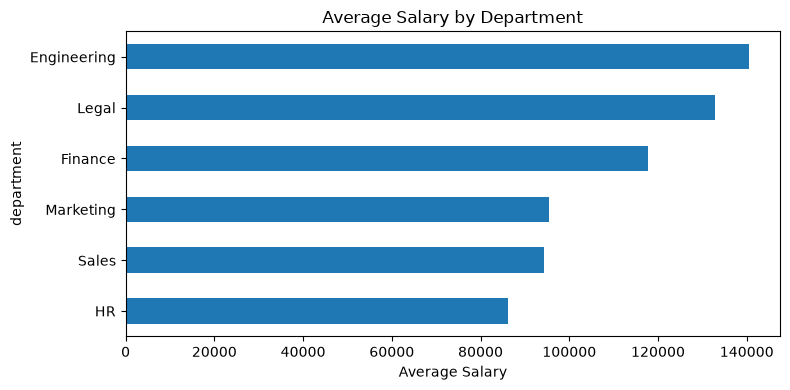

In [16]:
# visualize salary by department
df.groupby('department')['salary'].mean().sort_values().plot(
    kind = 'barh',
    title= 'Average Salary by Department',
    figsize = (8,4)
)

plt.xlabel('Average Salary')
plt.tight_layout()
plt.show()

In [17]:
# zipcode uniqueness
print(f"Unique zip codes: {df['zip_code'].nunique()}")
print(f"Total records: {len(df)}")

Unique zip codes: 4873
Total records: 5000


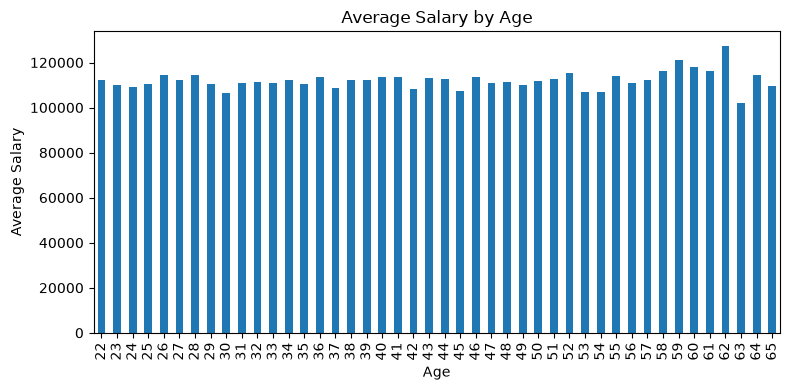

In [21]:
# visualize salary by age
df.groupby('age')['salary'].mean().sort_index().plot(
    kind='bar',
    title='Average Salary by Age',
    figsize=(8, 4)
)

plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.tight_layout()
plt.show()

# What do I observe?
# - Salary correlations:
Department type and salary correlations are realistic and this is important for the Mondrian algorithm to make meaningful generalization decisions, which only works if the data has real structure.
# - Take on distributions:
Each department has between 813 to 868 empolyee, this seems to be odd. In real HR dataset we'd expect Engineering to be much more larger than HR or Legal. This is a limitation of the synthetic generation (due to the usage of random.choice(departments)) - at the end this uniform distribution wouldn't impact the anonymization technique. In production, we prefer more actual org structure.
Age distribution shows there are more new grad hires than experienced employees, new grads count drop drastically - meaning they most of the times don't stay in the position, there is an increase in count with age 26 and older, so more experienced employees come back and stay until late 40s, while there is a jump for age 32 yrs - mid career.
# - Any data quality issues to fix before anonymization?
Nothing looks very wrong with the data - no negative values or nulls.
Zip code distribution shows almost every record has a unique zipcode (4873/5000) - this would make the generalization on zipcode, as one of the quisi-identifiers, hardest field to generalize and will drive the most of the information loss, which will change how we need to approach the Mondrian implementation.